In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pima-indians-diabetes-dataset' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-dataset


In [3]:
# Load the dataset
df = pd.read_csv(f'{path}/diabetes.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [4]:
# Display basic information about the dataset
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


None

In [5]:
# Select a numerical variable for bootstrap analysis (e.g., 'Glucose')
selected_variable = 'Glucose'

# Number of bootstrap samples
n_bootstraps = 10000

# Size of each bootstrap sample (can be the same as the original dataset size)
boot_sample_size = len(df)

# List to store bootstrap sample means
bootstrap_means = []

# Perform bootstrapping
for _ in range(n_bootstraps):
    # Draw a bootstrap sample with replacement
    bootstrap_sample = df[selected_variable].sample(n=boot_sample_size, replace=True)

    # Calculate the mean of the bootstrap sample
    bootstrap_mean = bootstrap_sample.mean()

    # Store the mean
    bootstrap_means.append(bootstrap_mean)

# Convert to a numpy array for easier calculations
bootstrap_means = np.array(bootstrap_means)

# Calculate the 95% confidence interval
confidence_interval_lower = np.percentile(bootstrap_means, 2.5)
confidence_interval_upper = np.percentile(bootstrap_means, 97.5)

print(f"Bootstrap 95% Confidence Interval for {selected_variable} Mean: ")
print(f"Lower bound: {confidence_interval_lower:.2f}")
print(f"Upper bound: {confidence_interval_upper:.2f}")

Bootstrap 95% Confidence Interval for Glucose Mean: 
Lower bound: 119.54
Upper bound: 123.85


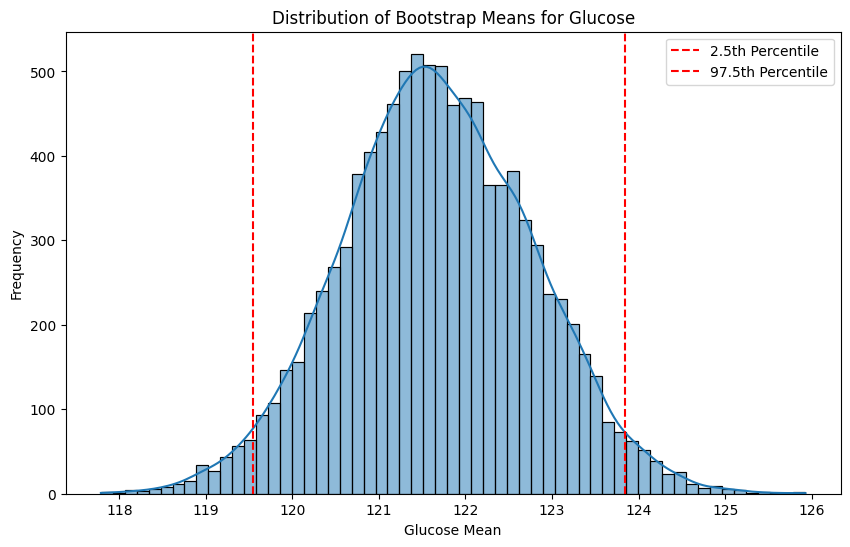

In [6]:
# Plot the distribution of bootstrap means
plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_means, kde=True)
plt.axvline(confidence_interval_lower, color='red', linestyle='--', label='2.5th Percentile')
plt.axvline(confidence_interval_upper, color='red', linestyle='--', label='97.5th Percentile')
plt.title(f'Distribution of Bootstrap Means for {selected_variable}')
plt.xlabel(f'{selected_variable} Mean')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [7]:
# Perform a permutation test for the difference in means between two groups (Outcome 0 and Outcome 1)

# Define the variable for which to test the difference
test_variable = 'Glucose'

# Separate data into two groups based on 'Outcome'
group_0 = df[df['Outcome'] == 0][test_variable]
group_1 = df[df['Outcome'] == 1][test_variable]

# Calculate the observed difference in means
observed_diff = group_1.mean() - group_0.mean()

print(f"Observed difference in {test_variable} means (Outcome 1 - Outcome 0): {observed_diff:.2f}")

# Number of permutations
n_permutations = 10000

# List to store permuted differences
perm_diffs = []

# Concatenate the two groups' data for shuffling
combined_data = pd.concat([group_0, group_1])

# Perform permutations
for _ in range(n_permutations):
    # Randomly permute the combined data
    permuted_data = np.random.permutation(combined_data)

    # Split the permuted data back into two groups of original sizes
    perm_group_0 = permuted_data[:len(group_0)]
    perm_group_1 = permuted_data[len(group_0):]

    # Calculate the difference in means for the permuted groups
    perm_diff = np.mean(perm_group_1) - np.mean(perm_group_0)

    perm_diffs.append(perm_diff)

# Convert to numpy array for easier calculations
perm_diffs = np.array(perm_diffs)

# Calculate the p-value
# Count how many permuted differences are as extreme or more extreme than the observed difference
p_value = np.sum(np.abs(perm_diffs) >= np.abs(observed_diff)) / n_permutations

print(f"P-value: {p_value:.4f}")

# Interpret the result
alpha = 0.05
if p_value < alpha:
    print(f"Since p-value ({p_value:.4f}) < alpha ({alpha}), we reject the null hypothesis.")
    print(f"There is a statistically significant difference in {test_variable} levels between the two outcome groups.")
else:
    print(f"Since p-value ({p_value:.4f}) >= alpha ({alpha}), we fail to reject the null hypothesis.")
    print(f"There is no statistically significant difference in {test_variable} levels between the two outcome groups.")

Observed difference in Glucose means (Outcome 1 - Outcome 0): 31.68
P-value: 0.0000
Since p-value (0.0000) < alpha (0.05), we reject the null hypothesis.
There is a statistically significant difference in Glucose levels between the two outcome groups.


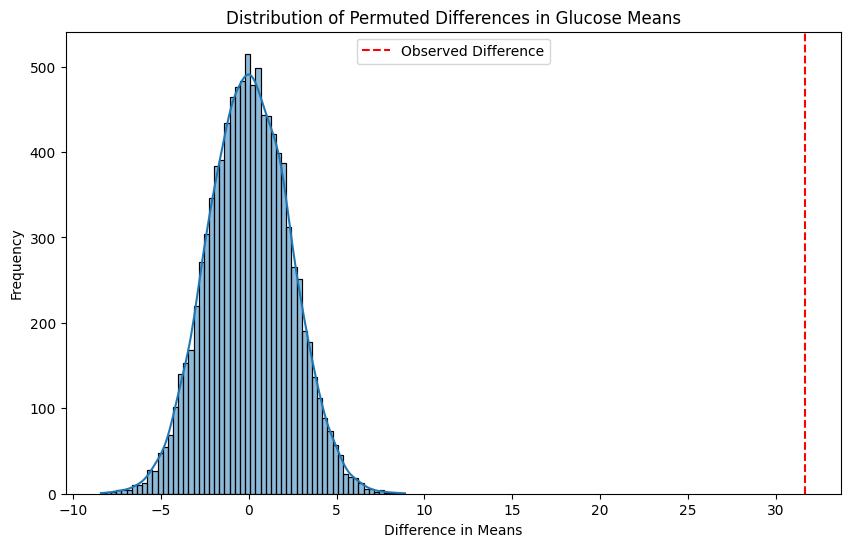

In [8]:
# Plot the distribution of permuted differences
plt.figure(figsize=(10, 6))
sns.histplot(perm_diffs, kde=True)
plt.axvline(observed_diff, color='red', linestyle='--', label='Observed Difference')
plt.title(f'Distribution of Permuted Differences in {test_variable} Means')
plt.xlabel('Difference in Means')
plt.ylabel('Frequency')
plt.legend()
plt.show()